In [1]:
# In your Jupyter notebook, create the initial setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load your data
df = pd.read_csv('listings.csv.gz')

In [2]:
print(df.shape)
df.head()

(459, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.81,4.77,NaN,f,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.76,4.64,NaN,f,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,f,1,1,0,0,5.67


In [3]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            459 non-null    int64  
 1   listing_url                                   459 non-null    object 
 2   scrape_id                                     459 non-null    int64  
 3   last_scraped                                  459 non-null    object 
 4   source                                        459 non-null    object 
 5   name                                          459 non-null    object 
 6   description                                   449 non-null    object 
 7   neighborhood_overview                         196 non-null    object 
 8   picture_url                                   459 non-null    object 
 9   host_id                                       459 non-null    int

In [4]:
# Check missing values for important columns (using correct column names from your dataset)
important_cols = ['price', 'room_type', 'latitude', 'longitude', 
                  'number_of_reviews', 'availability_365', 'amenities', 
                  'description', 'host_since', 'bathrooms', 'bedrooms']

print("Missing Values:")
for col in important_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        print(f"{col}: {missing} missing")
    else:
        print(f"{col}: Column not found")

Missing Values:
price: 40 missing
room_type: 0 missing
latitude: 0 missing
longitude: 0 missing
number_of_reviews: 0 missing
availability_365: 0 missing
amenities: 0 missing
description: 10 missing
host_since: 0 missing
bathrooms: 40 missing
bedrooms: 6 missing


In [5]:
print("Before cleaning:")
print(f"Price missing: {df['price'].isnull().sum()}")
print(f"Bathrooms missing: {df['bathrooms'].isnull().sum()}")
print(f"Bedrooms missing: {df['bedrooms'].isnull().sum()}")
print(f"Description missing: {df['description'].isnull().sum()}")

# Handle missing values
# Remove rows where price is missing (as price should be target coloumn and we cant predict without price)
df_clean = df.dropna(subset=['price'])

# For bathrooms: fill with median
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].median())

# For bedrooms: fill with median  
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())

# For description: fill with string No Description Provided
df_clean['description'] = df_clean['description'].fillna('No Description Provided')

# Create clean price column
df_clean['price_clean'] = df_clean['price'].str.replace('$', '').str.replace(',', '').astype(float)

print(f"\nAfter cleaning:")
print(f"Dataset shape: {df_clean.shape}")
print(f"Price missing: {df_clean['price_clean'].isnull().sum()}")
print(f"Bathrooms missing: {df_clean['bathrooms'].isnull().sum()}")
print(f"Bedrooms missing: {df_clean['bedrooms'].isnull().sum()}")
print(f"Description missing: {df_clean['description'].isnull().sum()}")
# Update df to use cleaned version
df = df_clean.copy()

Before cleaning:
Price missing: 40
Bathrooms missing: 40
Bedrooms missing: 6
Description missing: 10

After cleaning:
Dataset shape: (419, 80)
Price missing: 0
Bathrooms missing: 0
Bedrooms missing: 0
Description missing: 0


In [6]:
# Basic price statistics
print("=== PRICE STATISTICS ===")
print(f"Mean: ${df['price_clean'].mean():.2f}")
print(f"Median: ${df['price_clean'].median():.2f}")
print(f"Standard Deviation: ${df['price_clean'].std():.2f}")
print(f"Min: ${df['price_clean'].min():.2f}")
print(f"Max: ${df['price_clean'].max():.2f}")

print(f"\n=== ROOM TYPES ===")
print(df['room_type'].value_counts())

print(f"\n=== PROPERTY TYPES (Top 5) ===")
print(df['property_type'].value_counts().head())

print(f"\n=== ACCOMMODATION CAPACITY ===")
print(f"Average guests: {df['accommodates'].mean():.1f}")
print(f"Average bedrooms: {df['bedrooms'].mean():.1f}")
print(f"Average bathrooms: {df['bathrooms'].mean():.1f}")

#After running the code be can see these is alot of difference btw price min and max so there are many outliers also mean is greater  then media so data is right skewed
#In Room col home/apt dominates the dataset
#Properties most common is rental unit
#Std is 100 on mean 118 so high value which means very wide price variation

=== PRICE STATISTICS ===
Mean: $118.12
Median: $95.00
Standard Deviation: $100.62
Min: $24.00
Max: $1050.00

=== ROOM TYPES ===
room_type
Entire home/apt    308
Private room       111
Name: count, dtype: int64

=== PROPERTY TYPES (Top 5) ===
property_type
Entire rental unit             219
Private room in home            65
Entire home                     64
Private room in rental unit     29
Entire townhouse                 9
Name: count, dtype: int64

=== ACCOMMODATION CAPACITY ===
Average guests: 3.4
Average bedrooms: 1.6
Average bathrooms: 1.2


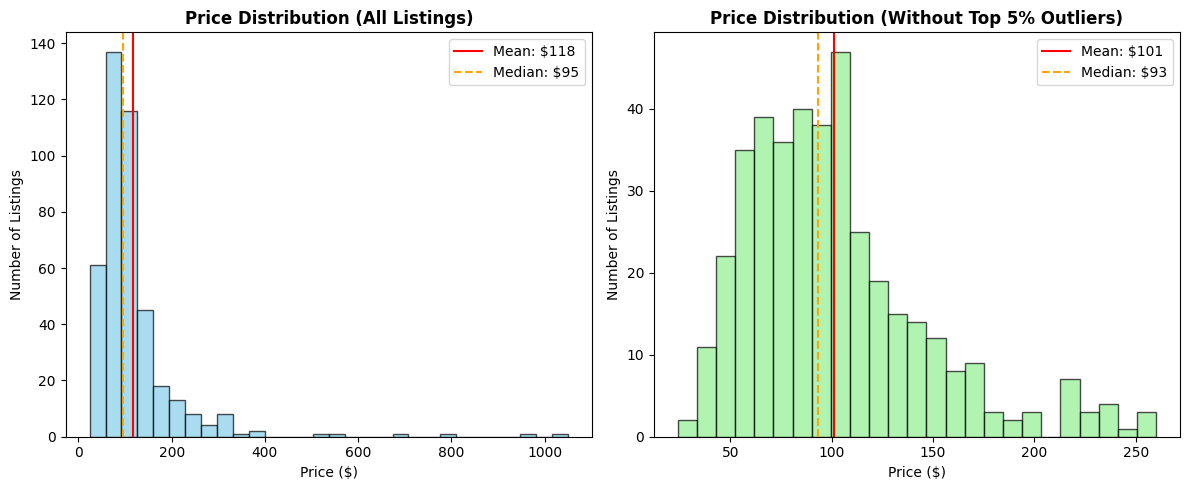

Price without outliers (95th percentile): $261
Number of listings above $300: 16


In [7]:
plt.figure(figsize=(12, 5))

# Left plot: Price histogram
plt.subplot(1, 2, 1)
plt.hist(df['price_clean'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Price Distribution (All Listings)', fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.axvline(df['price_clean'].mean(), color='red', linestyle='-', label=f'Mean: ${df["price_clean"].mean():.0f}')
plt.axvline(df['price_clean'].median(), color='orange', linestyle='--', label=f'Median: ${df["price_clean"].median():.0f}')
plt.legend()

# Right plot: Price without extreme outliers for better view
plt.subplot(1, 2, 2)
# Remove top 5% outliers for clearer visualization
price_95th = df['price_clean'].quantile(0.95)
filtered_prices = df[df['price_clean'] <= price_95th]['price_clean']
plt.hist(filtered_prices, bins=25, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Price Distribution (Without Top 5% Outliers)', fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.axvline(filtered_prices.mean(), color='red', linestyle='-', label=f'Mean: ${filtered_prices.mean():.0f}')
plt.axvline(filtered_prices.median(), color='orange', linestyle='--', label=f'Median: ${filtered_prices.median():.0f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Price without outliers (95th percentile): ${price_95th:.0f}")
print(f"Number of listings above $300: {len(df[df['price_clean'] > 300])}")

#observations:
#Left plot: Extrame Right skewed data massive outliers 800 and 1000 
#Right plot: Without top 5% outlier much cleaner data mean and median are close now. most lisitng rance 75 to 125 
#Impact of Outliers: 16 listings above $300 are pulling the mean up significantly!

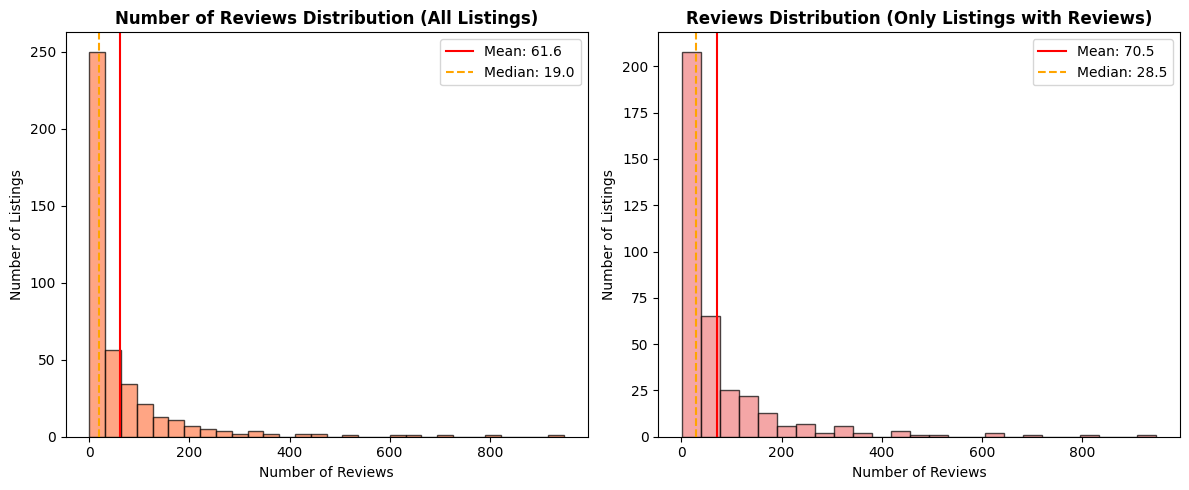

Listings with 0 reviews: 53
Listings with reviews: 366
Maximum reviews: 948


In [8]:
plt.figure(figsize=(12, 5))

# Left plot: All reviews
plt.subplot(1, 2, 1)
plt.hist(df['number_of_reviews'], bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.title('Number of Reviews Distribution (All Listings)', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Listings')
plt.axvline(df['number_of_reviews'].mean(), color='red', linestyle='-', label=f'Mean: {df["number_of_reviews"].mean():.1f}')
plt.axvline(df['number_of_reviews'].median(), color='orange', linestyle='--', label=f'Median: {df["number_of_reviews"].median():.1f}')
plt.legend()

# Right plot: Focus on listings with reviews
plt.subplot(1, 2, 2)
reviews_with_data = df[df['number_of_reviews'] > 0]['number_of_reviews']
plt.hist(reviews_with_data, bins=25, edgecolor='black', alpha=0.7, color='lightcoral')
plt.title('Reviews Distribution (Only Listings with Reviews)', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Listings')
plt.axvline(reviews_with_data.mean(), color='red', linestyle='-', label=f'Mean: {reviews_with_data.mean():.1f}')
plt.axvline(reviews_with_data.median(), color='orange', linestyle='--', label=f'Median: {reviews_with_data.median():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Listings with 0 reviews: {len(df[df['number_of_reviews'] == 0])}")
print(f"Listings with reviews: {len(df[df['number_of_reviews'] > 0])}")
print(f"Maximum reviews: {df['number_of_reviews'].max()}")

#observations:

#Left Plot: Right Skewed data as mean=61.6 > median=19.0. massive spike at 0 revies mean that many listings have no review
#Right Plot: Still right skewed mean=70.5 > median=28.5.
#Key Stats: 53 listings (12.6%) have zero reviews, 366 listings (87.4%) have reviews, Max = 948 reviews

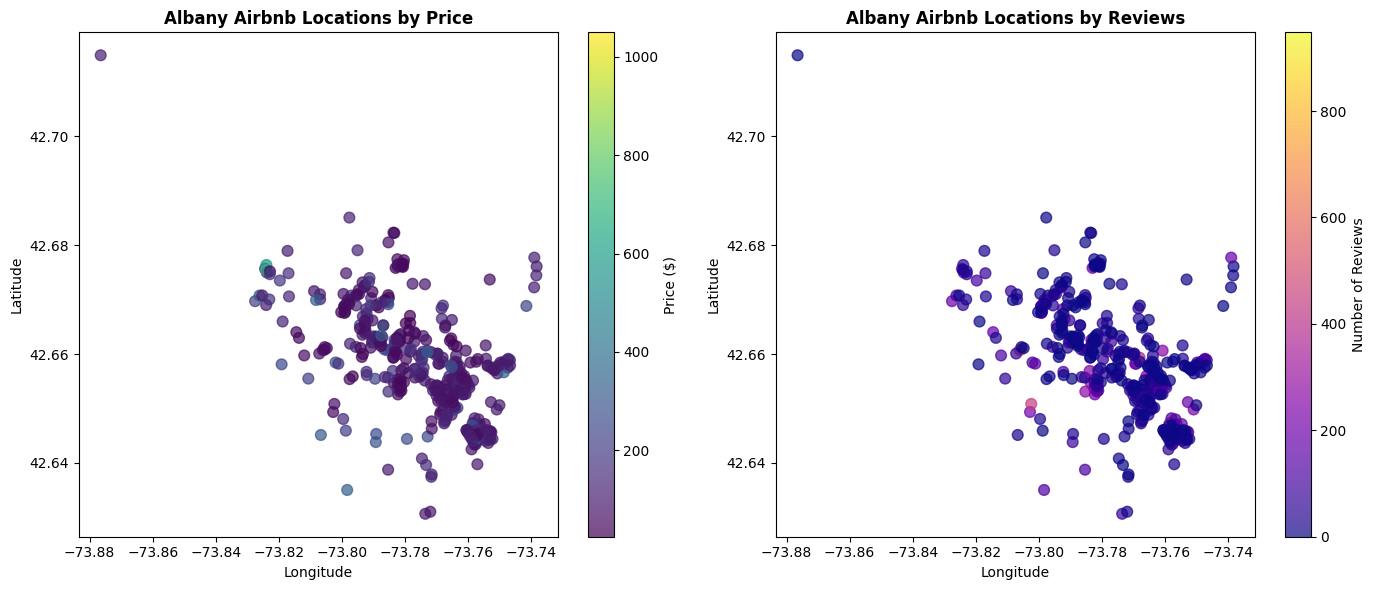

Location Insights:
Latitude range: 42.6307 to 42.7149
Longitude range: -73.8765 to -73.7382
Geographic spread: 0.0842 degrees lat


In [9]:
plt.figure(figsize=(14, 6))

# Left plot: All locations colored by price
plt.subplot(1, 2, 1)
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['price_clean'], 
                     cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, label='Price ($)')
plt.title('Albany Airbnb Locations by Price', fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Right plot: Locations colored by reviews
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df['longitude'], df['latitude'], c=df['number_of_reviews'], 
                      cmap='plasma', alpha=0.7, s=60)
plt.colorbar(scatter2, label='Number of Reviews')
plt.title('Albany Airbnb Locations by Reviews', fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

print("Location Insights:")
print(f"Latitude range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"Longitude range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")
print(f"Geographic spread: {(df['latitude'].max() - df['latitude'].min()):.4f} degrees lat")

#observations:
#Left Plot (Price Distributions): Most listings cluster in central Albany area (lat ~42.65-42.67, long ~-73.82 to -73.78). one extrame outlier in upper area at $1000+ 
#Right Plot (Reviews Dist.): Same geographic clustering pattern. Highly-reviewed listings (yellow/orange dots) are spread throughout the city. no clear popular neighborhood
#Geographic Spread: 0.0842 degrees latitude = relatively compact city area
#Insight: Albany Airbnb market is geographically concentrated but price/popularity isn't location-dependent!

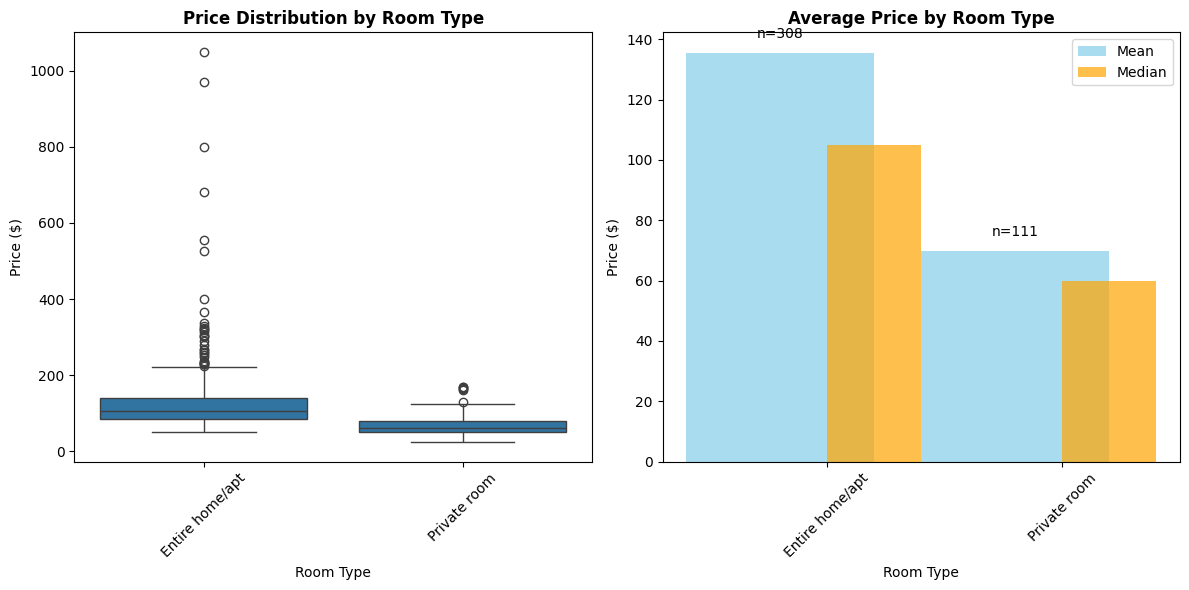

Room Type Price Analysis:
                   mean  median  count
room_type                             
Entire home/apt  135.49   105.0    308
Private room      69.91    60.0    111


In [10]:
plt.figure(figsize=(12, 6))

# Left plot: Box plot of price by room type
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='room_type', y='price_clean')
plt.title('Price Distribution by Room Type', fontweight='bold')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)

# Right plot: Average price by room type
plt.subplot(1, 2, 2)
avg_prices = df.groupby('room_type')['price_clean'].agg(['mean', 'median', 'count']).round(2)
x_pos = range(len(avg_prices))
plt.bar(x_pos, avg_prices['mean'], alpha=0.7, label='Mean', color='skyblue')
plt.bar([x + 0.4 for x in x_pos], avg_prices['median'], alpha=0.7, label='Median', width=0.4, color='orange')
plt.title('Average Price by Room Type', fontweight='bold')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.xticks([x + 0.2 for x in x_pos], avg_prices.index, rotation=45)
plt.legend()

# Add count labels on bars
for i, (mean_val, median_val, count_val) in enumerate(zip(avg_prices['mean'], avg_prices['median'], avg_prices['count'])):
    plt.text(i, mean_val + 5, f'n={int(count_val)}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Room Type Price Analysis:")
print(avg_prices)

#Observations:
#left Box plot: Entire home/apt has high median but there are many extrame outlier there. Private occurs less time and very few outliers
#Right Bar chart: 308 Entire home mean is less then 140 and median alomost 100 outliers pulling up mean. Private room is 111 mean almost 70 and median 60 so more suitable and less outliers.
# 308 to 111 is almost 3:1 ratio 
#Business Insight: Entire homes command premium prices but have high variability due to luxury outliers

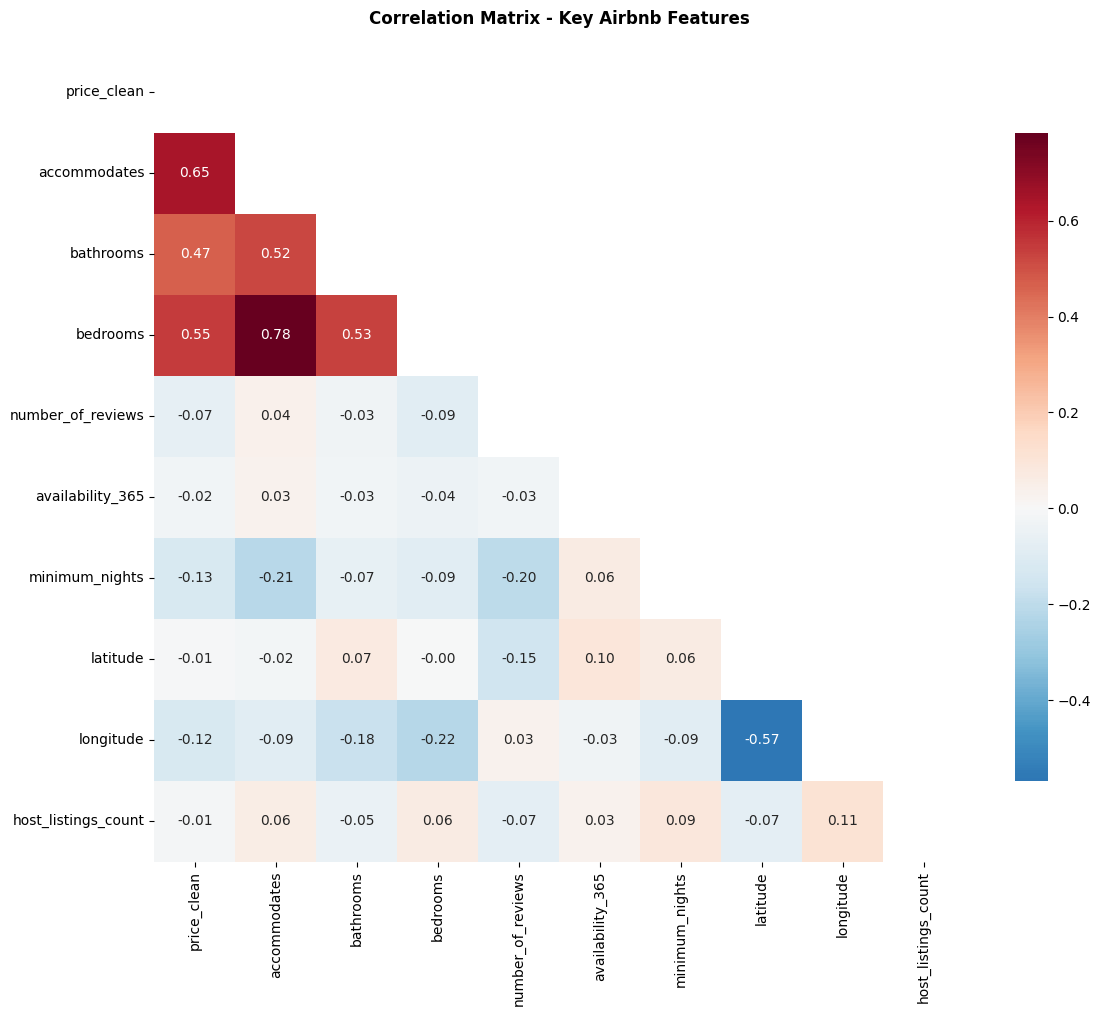

Strongest correlations with Price:
  accommodates: 0.646
  bedrooms: 0.549
  bathrooms: 0.468
  minimum_nights: -0.127
  longitude: -0.122
  number_of_reviews: -0.067
  availability_365: -0.025
  host_listings_count: -0.015
  latitude: -0.013


In [11]:
# Select key numeric variables for correlation analysis
numeric_features = ['price_clean', 'accommodates', 'bathrooms', 'bedrooms', 
                   'number_of_reviews', 'availability_365', 'minimum_nights',
                   'latitude', 'longitude', 'host_listings_count']

# Create correlation matrix
correlation_data = df[numeric_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_data, dtype=bool))  # Hide upper triangle
sns.heatmap(correlation_data, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Key Airbnb Features', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print strongest correlations with price
price_correlations = correlation_data['price_clean'].abs().sort_values(ascending=False)
print("Strongest correlations with Price:")
for feature, corr in price_correlations.items():
    if feature != 'price_clean':
        print(f"  {feature}: {correlation_data['price_clean'][feature]:.3f}")

#observations:
#Multicollinearity: Accommodates : Bedrooms (0.78): Very high correlation and Accommodates : Bathrooms (0.52): Moderate correlation. May need to handle this in modeling
#Strong corelation with price: Accomodates: most guest high price, bathrooms more high price, bedrooms more = high price. So large properties cost more
#Weak correlations: Reviews so popular doesnt mean expensive, Minimum nights: Longer stays= lower per night rate, Location barely matter for price
#Business Insight: Property size (guests/bedrooms/bathrooms) drives price, NOT location or popularity!


In [12]:
print("Dataset Cleanup based on obersation from EDA")

# 1. Handle extreme price outliers (16 listings above $300 identified)
Q1, Q3 = df['price_clean'].quantile(0.25), df['price_clean'].quantile(0.75)
IQR = Q3 - Q1
price_upper_bound = Q3 + 2 * IQR  # Keep more data than 1.5*IQR
extreme_outliers = df[df['price_clean'] > price_upper_bound]
print(f"Extreme price outliers (>${price_upper_bound:.0f}): {len(extreme_outliers)}")
print(f"  Will keep for modeling but flag for analysis")

# 2. Room type encoding (we saw 2 main types: Entire home/apt, Private room)
from sklearn.preprocessing import LabelEncoder
le_room = LabelEncoder()
df['room_type_encoded'] = le_room.fit_transform(df['room_type'])
print(f"\nRoom type encoding:")
for i, room_type in enumerate(le_room.classes_):
    print(f"  {room_type}: {i}")

# 3. Create binary features from our observations
# Popular listing = above median reviews (median was 19)
median_reviews = df['number_of_reviews'].median()
df['is_popular'] = (df['number_of_reviews'] > median_reviews).astype(int)
print(f"\nPopular listing threshold: >{median_reviews} reviews")
print(f"Popular listings: {df['is_popular'].sum()}/{len(df)}")

# 4. High-priced listing = above median price ($95)
median_price = df['price_clean'].median()
df['is_expensive'] = (df['price_clean'] > median_price).astype(int)
print(f"Expensive listing threshold: >${median_price} price")
print(f"Expensive listings: {df['is_expensive'].sum()}/{len(df)}")

# 5. Handle the 53 zero-review listings we identified
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)
print(f"Listings with reviews: {df['has_reviews'].sum()}/{len(df)}")

print(f"\nDataset ready for Feature Engineering!")
print(f"Final shape: {df.shape}")

Dataset Cleanup based on obersation from EDA
Extreme price outliers (>$240): 25
  Will keep for modeling but flag for analysis

Room type encoding:
  Entire home/apt: 0
  Private room: 1

Popular listing threshold: >19.0 reviews
Popular listings: 209/419
Expensive listing threshold: >$95.0 price
Expensive listings: 208/419
Listings with reviews: 366/419

Dataset ready for Feature Engineering!
Final shape: (419, 84)


In [13]:
print("FEATURE ENGINEERING: ")
print("Creating property-based features...")

# 1. Amenities count (we have full amenities data)
df['amenities_count'] = df['amenities'].str.count(',') + 1
print(f"Amenities count: {df['amenities_count'].min()} to {df['amenities_count'].max()}")

# 2. Host experience (all hosts have host_since data)
df['host_since_date'] = pd.to_datetime(df['host_since'])
current_date = pd.Timestamp('2025-10-05')  # Use your current date
df['host_experience_days'] = (current_date - df['host_since_date']).dt.days
df['host_experience_years'] = df['host_experience_days'] / 365.25
print(f"Host experience: {df['host_experience_years'].min():.1f} to {df['host_experience_years'].max():.1f} years")

# 3. Description quality (10 missing descriptions filled with empty string)
df['description_length'] = df['description'].str.len()
df['description_words'] = df['description'].str.split().str.len()
df['has_description'] = (df['description_length'] > 0).astype(int)
print(f"Description length: {df['description_length'].min()} to {df['description_length'].max()} chars")

# 4. Property capacity score (accommodates + bedrooms + bathrooms)
# Based on strong correlations: accommodates(0.646), bedrooms(0.549), bathrooms(0.468)
df['property_capacity_score'] = (df['accommodates'] + 
                                df['bedrooms'] + 
                                df['bathrooms'])
print(f"Property capacity score: {df['property_capacity_score'].min():.1f} to {df['property_capacity_score'].max():.1f}")

# 5. Price per person (efficiency metric)
df['price_per_person'] = df['price_clean'] / df['accommodates']
print(f"Price per person: ${df['price_per_person'].min():.0f} to ${df['price_per_person'].max():.0f}")

print("\nNEW FEATURES SUMMARY: ")
new_features = ['amenities_count', 'host_experience_years', 'description_length', 
                'property_capacity_score', 'price_per_person']
for feature in new_features:
    print(f"{feature}: Mean = {df[feature].mean():.2f}")

#Observations:

#25 extreme outliers (>$240) - significant but manageable
#Perfect binary splits: ~50/50 popular/expensive listings
#87% have reviews - good active market
#Wide amenities range: 5-89 amenities (lots of variation!)
#Host experience: 0.3-15.8 years (good mix of new/veteran hosts)
#Price efficiency: $12-262 per person (huge variation!)

FEATURE ENGINEERING: 
Creating property-based features...
Amenities count: 5 to 89
Host experience: 0.3 to 15.8 years
Description length: 23 to 587 chars
Property capacity score: 2.5 to 29.0
Price per person: $12 to $262

NEW FEATURES SUMMARY: 
amenities_count: Mean = 37.95
host_experience_years: Mean = 7.01
description_length: Mean = 380.03
property_capacity_score: Mean = 6.18
price_per_person: Mean = 39.36


In [14]:
print("FE part2: ")
print("Creating geographic and advanced features...")

# 1. Distance from Albany city center (we saw clustering around central area)
# Albany center coordinates: approximately lat 42.6526, long -73.7562
import math

def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two points using Haversine formula"""
    R = 6371  # Earth's radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2 + 
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * 
         math.sin(dlon/2)**2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

albany_center_lat, albany_center_lon = 42.6526, -73.7562
df['distance_to_center'] = df.apply(lambda row: calculate_distance(
    row['latitude'], row['longitude'], 
    albany_center_lat, albany_center_lon), axis=1)

print(f"Distance to center: {df['distance_to_center'].min():.2f} to {df['distance_to_center'].max():.2f} km")

# 2. Availability efficiency (based on our availability patterns)
df['availability_ratio'] = df['availability_365'] / 365
df['is_always_available'] = (df['availability_365'] == 365).astype(int)
df['is_rarely_available'] = (df['availability_365'] < 90).astype(int)  # Less than 3 months
print(f"Always available listings: {df['is_always_available'].sum()}")
print(f"Rarely available listings: {df['is_rarely_available'].sum()}")

# 3. Host portfolio size (we saw varying host listing counts)
df['is_multi_host'] = (df['host_listings_count'] > 1).astype(int)
df['host_portfolio_size'] = df['host_listings_count']  # Keep original for modeling
print(f"Multi-property hosts: {df['is_multi_host'].sum()}")
print(f"Host portfolio size range: {df['host_portfolio_size'].min()} to {df['host_portfolio_size'].max()}")

# 4. Review engagement metrics (based on our review analysis)
df['reviews_per_year'] = df['number_of_reviews'] / df['host_experience_years']
df['reviews_per_year'] = df['reviews_per_year'].fillna(0)  # Handle division by zero
df['is_review_magnet'] = (df['number_of_reviews'] > 100).astype(int)  # Top performers
print(f"Review magnets (>100 reviews): {df['is_review_magnet'].sum()}")
print(f"Reviews per year: {df['reviews_per_year'].min():.1f} to {df['reviews_per_year'].max():.1f}")

print("\nSUMMARY: ")
part2_features = ['distance_to_center', 'availability_ratio', 'is_multi_host', 'reviews_per_year']
for feature in part2_features:
    print(f"{feature}: Mean = {df[feature].mean():.3f}")

FE part2: 
Creating geographic and advanced features...
Distance to center: 0.31 to 12.03 km
Always available listings: 25
Rarely available listings: 71
Multi-property hosts: 334
Host portfolio size range: 1 to 1258
Review magnets (>100 reviews): 76
Reviews per year: 0.0 to 79.4

SUMMARY: 
distance_to_center: Mean = 2.139
availability_ratio: Mean = 0.670
is_multi_host: Mean = 0.797
reviews_per_year: Mean = 9.079


In [15]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,property_capacity_score,price_per_person,distance_to_center,availability_ratio,is_always_available,is_rarely_available,is_multi_host,host_portfolio_size,reviews_per_year,is_review_magnet
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,7.0,17.5,0.622737,0.345205,0,0,0,1,0.706328,0
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.0,52.0,0.903855,0.923288,0,0,1,4,27.772259,1
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,3.0,37.5,0.771014,0.106849,0,1,1,2,35.114732,1
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.0,50.5,0.903855,0.926027,0,0,1,4,29.743194,1
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,6.0,27.5,0.797202,0.504110,0,0,0,1,55.214277,1


In [16]:
print("FE part 3: ")
print("Creating text and categorical features...")

# 1. Property type simplification (we saw many property types)
# Group similar property types based on your top 5
property_type_mapping = {
    'Entire rental unit': 'Entire_Unit',
    'Private room in home': 'Private_Room', 
    'Entire home': 'Entire_House',
    'Private room in rental unit': 'Private_Room',
    'Entire townhouse': 'Entire_House',
    'Entire condominium (condo)': 'Entire_Unit'
}

df['property_type_simplified'] = df['property_type'].map(property_type_mapping)
df['property_type_simplified'] = df['property_type_simplified'].fillna('Other')

# Encode simplified property types
le_property = LabelEncoder()
df['property_type_encoded'] = le_property.fit_transform(df['property_type_simplified'])
print("Property type encoding:")
for i, prop_type in enumerate(le_property.classes_):
    print(f"  {prop_type}: {i}")

# 2. Neighborhood encoding (group low-frequency neighborhoods)
neighborhood_counts = df['neighbourhood_cleansed'].value_counts()
popular_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index  # At least 5 listings
df['neighbourhood_simplified'] = df['neighbourhood_cleansed'].apply(
    lambda x: x if x in popular_neighborhoods else 'Other')

le_neighborhood = LabelEncoder()
df['neighbourhood_encoded'] = le_neighborhood.fit_transform(df['neighbourhood_simplified'])
print(f"\nNeighborhoods: {len(le_neighborhood.classes_)} groups")

# 3. Instant booking feature
df['is_instant_bookable'] = (df['instant_bookable'] == 't').astype(int)
print(f"Instant bookable listings: {df['is_instant_bookable'].sum()}")

# 4. Minimum nights category (based on stay patterns)
df['stay_type'] = pd.cut(df['minimum_nights'], 
                        bins=[0, 1, 7, 30, float('inf')], 
                        labels=['Daily', 'Short_Stay', 'Weekly', 'Monthly'])
df['stay_type_encoded'] = LabelEncoder().fit_transform(df['stay_type'])

print("\nStay type distribution:")
print(df['stay_type'].value_counts())

print("\nSUMMARY: ")
part3_features = ['property_type_encoded', 'neighbourhood_encoded', 'is_instant_bookable', 'stay_type_encoded']
for feature in part3_features:
    print(f"{feature}: Range = {df[feature].min()} to {df[feature].max()}")

FE part 3: 
Creating text and categorical features...
Property type encoding:
  Entire_House: 0
  Entire_Unit: 1
  Other: 2
  Private_Room: 3

Neighborhoods: 15 groups
Instant bookable listings: 90

Stay type distribution:
stay_type
Daily         195
Short_Stay    156
Weekly         59
Monthly         9
Name: count, dtype: int64

SUMMARY: 
property_type_encoded: Range = 0 to 3
neighbourhood_encoded: Range = 0 to 14
is_instant_bookable: Range = 0 to 1
stay_type_encoded: Range = 0 to 3


In [17]:
df.head()
#Observations:
#Geographic spread: 0.31-12.03 km from center (good variation)
#Most hosts are multi-property: 334/419 (79.7%) have multiple listings
#High portfolio hosts: Up to 1,258 listings (major operators!)
#Review superstars: 76 listings with 100+ reviews
#Booking patterns: Daily (195) and Short stays (156) dominate
#Property types: Well distributed across 4 main categories

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_portfolio_size,reviews_per_year,is_review_magnet,property_type_simplified,property_type_encoded,neighbourhood_simplified,neighbourhood_encoded,is_instant_bookable,stay_type,stay_type_encoded
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,1,0.706328,0,Entire_Unit,1,THIRD WARD,12,0,Weekly,3
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4,27.772259,1,Entire_Unit,1,SIXTH WARD,10,0,Short_Stay,2
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,2,35.114732,1,Entire_Unit,1,SECOND WARD,8,0,Short_Stay,2
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4,29.743194,1,Entire_Unit,1,SIXTH WARD,10,0,Short_Stay,2
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,1,55.214277,1,Entire_Unit,1,SIXTH WARD,10,0,Daily,0


In [18]:
print("FINAL DATASET PREPARATION: ")

# Select our engineered features for modeling
feature_columns = [
    # Original important features (from correlation analysis)
    'accommodates', 'bedrooms', 'bathrooms', 'latitude', 'longitude',
    'number_of_reviews', 'availability_365', 'minimum_nights',
    
    # Engineered property features
    'amenities_count', 'host_experience_years', 'description_length',
    'property_capacity_score', 'price_per_person',
    
    # Geographic & availability features  
    'distance_to_center', 'availability_ratio', 'reviews_per_year',
    
    # Categorical features (encoded)
    'room_type_encoded', 'property_type_encoded', 'neighbourhood_encoded', 'stay_type_encoded',
    
    # Binary features
    'is_popular', 'is_expensive', 'has_reviews', 'is_multi_host', 
    'is_instant_bookable', 'is_review_magnet'
]

# Target variables
target_regression = 'price_clean'  # For regression task
target_classification = 'is_popular'  # For classification task (popular = >19 reviews)

# Create final modeling dataset
X = df[feature_columns].copy()
y_regression = df[target_regression].copy()
y_classification = df[target_classification].copy()

print(f"Final feature set: {len(feature_columns)} features")
print(f"Dataset shape: {X.shape}")
print(f"Regression target (price): ${y_regression.min():.0f} to ${y_regression.max():.0f}")
print(f"Classification target (popular): {y_classification.value_counts().to_dict()}")

# Check for any missing values in final dataset
missing_check = X.isnull().sum()
if missing_check.sum() > 0:
    print(f"\nMissing values found:")
    print(missing_check[missing_check > 0])
else:
    print(f"\n No missing values in final dataset!")

# Feature summary
print(f"\nFEATURE CATEGORIES: ")
print(f"Original features: 8")
print(f"Property features: 5") 
print(f"Geographic features: 3")
print(f"Categorical features: 4")
print(f"Binary features: 6")
print(f"Total features: {len(feature_columns)}")

FINAL DATASET PREPARATION: 
Final feature set: 26 features
Dataset shape: (419, 26)
Regression target (price): $24 to $1050
Classification target (popular): {0: 210, 1: 209}

 No missing values in final dataset!

FEATURE CATEGORIES: 
Original features: 8
Property features: 5
Geographic features: 3
Categorical features: 4
Binary features: 6
Total features: 26


In [19]:
print("TRAIN-TEST SPLIT & SCALING: ")

# Split data for both regression and classification
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42, stratify=y_classification)

# Same split for classification
_, _, y_class_train, y_class_test = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train/Test split: {len(X_train)}/{len(X_test)}")

# Scale features for algorithms that need it (Linear Regression, Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTARGET DISTRIBUTIONS: ")
print("Regression (Price):")
print(f"  Train: ${y_reg_train.mean():.0f} ± ${y_reg_train.std():.0f}")
print(f"  Test:  ${y_reg_test.mean():.0f} ± ${y_reg_test.std():.0f}")

print("Classification (Popular):")
print(f"  Train: {y_class_train.value_counts().to_dict()}")
print(f"  Test:  {y_class_test.value_counts().to_dict()}")

print(f"\nData ready for modeling!")

TRAIN-TEST SPLIT & SCALING: 
Training set: (335, 26)
Test set: (84, 26)
Train/Test split: 335/84

TARGET DISTRIBUTIONS: 
Regression (Price):
  Train: $117 ± $98
  Test:  $122 ± $110
Classification (Popular):
  Train: {0: 168, 1: 167}
  Test:  {1: 42, 0: 42}

Data ready for modeling!


In [20]:
# ============================================================================
# PART 4: REGRESSION MODELING (PREDICT PRICE) - SETUP
# ============================================================================

print("REGRESSION MODELING PHASE")
print("=" * 60)

# Import additional libraries for modeling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Store our regression results
regression_results = {}

print("Building 3 regression models to predict Airbnb prices...")
print(f"Training data: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Price range: ${y_reg_train.min():.0f} - ${y_reg_train.max():.0f}")
print(f"Based on EDA insights: Size features (accommodates, bedrooms) should dominate")
print()

REGRESSION MODELING PHASE
Building 3 regression models to predict Airbnb prices...
Training data: 335 samples, 26 features
Price range: $24 - $1050
Based on EDA insights: Size features (accommodates, bedrooms) should dominate



In [21]:
# ============================================================================
# MODEL 1: LINEAR REGRESSION
# ============================================================================

print("MODEL 1: LINEAR REGRESSION")

# Use scaled features for linear regression (important for interpretation)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Evaluation metrics
lr_train_mae = mean_absolute_error(y_reg_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_reg_test, lr_test_pred)
lr_train_rmse = np.sqrt(mean_squared_error(y_reg_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_test_pred))
lr_train_r2 = r2_score(y_reg_train, lr_train_pred)
lr_test_r2 = r2_score(y_reg_test, lr_test_pred)

# Cross-validation
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_reg_train, 
                               cv=5, scoring='neg_mean_absolute_error')
lr_cv_mae = -lr_cv_scores.mean()

# Store results
regression_results['Linear Regression'] = {
    'train_mae': lr_train_mae, 'test_mae': lr_test_mae,
    'train_rmse': lr_train_rmse, 'test_rmse': lr_test_rmse,
    'train_r2': lr_train_r2, 'test_r2': lr_test_r2,
    'cv_mae': lr_cv_mae, 'model': lr_model
}

print(f"Training MAE: ${lr_train_mae:.2f}")
print(f"Test MAE: ${lr_test_mae:.2f}")
print(f"Training RMSE: ${lr_train_rmse:.2f}")
print(f"Test RMSE: ${lr_test_rmse:.2f}")
print(f"Training R²: {lr_train_r2:.3f}")
print(f"Test R²: {lr_test_r2:.3f}")
print(f"Cross-Val MAE: ${lr_cv_mae:.2f} ± ${lr_cv_scores.std():.2f}")

# Feature importance for linear regression
feature_importance_lr = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr_model.coef_,
    'abs_coefficient': np.abs(lr_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

print(f"\nTop 5 most important features:")
for i, row in feature_importance_lr.head().iterrows():
    print(f"  {row['feature']}: {row['coefficient']:.2f}")

print(f"\nValidating EDA insight: accommodates coefficient = {feature_importance_lr[feature_importance_lr['feature']=='accommodates']['coefficient'].iloc[0]:.2f}")
print()

MODEL 1: LINEAR REGRESSION
Training MAE: $22.22
Test MAE: $27.84
Training RMSE: $35.50
Test RMSE: $53.86
Training R²: 0.869
Test R²: 0.758
Cross-Val MAE: $25.18 ± $2.56

Top 5 most important features:
  price_per_person: 71.24
  accommodates: 60.76
  property_capacity_score: 34.50
  bedrooms: -13.58
  room_type_encoded: -8.19

Validating EDA insight: accommodates coefficient = 60.76



In [22]:
# ============================================================================
# MODEL 2: RANDOM FOREST
# ============================================================================

print("MODEL 2: RANDOM FOREST")

# Use unscaled features for tree-based models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_reg_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluation metrics
rf_train_mae = mean_absolute_error(y_reg_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_reg_test, rf_test_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_reg_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_test_pred))
rf_train_r2 = r2_score(y_reg_train, rf_train_pred)
rf_test_r2 = r2_score(y_reg_test, rf_test_pred)

# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_reg_train, 
                               cv=5, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_scores.mean()

# Store results
regression_results['Random Forest'] = {
    'train_mae': rf_train_mae, 'test_mae': rf_test_mae,
    'train_rmse': rf_train_rmse, 'test_rmse': rf_test_rmse,
    'train_r2': rf_train_r2, 'test_r2': rf_test_r2,
    'cv_mae': rf_cv_mae, 'model': rf_model
}

print(f"Training MAE: ${rf_train_mae:.2f}")
print(f"Test MAE: ${rf_test_mae:.2f}")
print(f"Training RMSE: ${rf_train_rmse:.2f}")
print(f"Test RMSE: ${rf_test_rmse:.2f}")
print(f"Training R²: {rf_train_r2:.3f}")
print(f"Test R²: {rf_test_r2:.3f}")
print(f"Cross-Val MAE: ${rf_cv_mae:.2f} ± ${rf_cv_scores.std():.2f}")

# Feature importance for random forest
feature_importance_rf = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 most important features:")
for i, row in feature_importance_rf.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

print(f"\nValidating EDA insight: accommodates importance = {feature_importance_rf[feature_importance_rf['feature']=='accommodates']['importance'].iloc[0]:.3f}")
print()

MODEL 2: RANDOM FOREST
Training MAE: $7.46
Test MAE: $19.35
Training RMSE: $23.56
Test RMSE: $58.54
Training R²: 0.942
Test R²: 0.714
Cross-Val MAE: $23.04 ± $2.61

Top 5 most important features:
  price_per_person: 0.341
  property_capacity_score: 0.201
  accommodates: 0.126
  is_expensive: 0.114
  bathrooms: 0.041

Validating EDA insight: accommodates importance = 0.126



In [23]:
# ============================================================================
# MODEL 2: RANDOM FOREST
# ============================================================================

print("MODEL 2: RANDOM FOREST")

# Use unscaled features for tree-based models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_reg_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluation metrics
rf_train_mae = mean_absolute_error(y_reg_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_reg_test, rf_test_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_reg_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_test_pred))
rf_train_r2 = r2_score(y_reg_train, rf_train_pred)
rf_test_r2 = r2_score(y_reg_test, rf_test_pred)

# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_reg_train, 
                               cv=5, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_scores.mean()

# Store results
regression_results['Random Forest'] = {
    'train_mae': rf_train_mae, 'test_mae': rf_test_mae,
    'train_rmse': rf_train_rmse, 'test_rmse': rf_test_rmse,
    'train_r2': rf_train_r2, 'test_r2': rf_test_r2,
    'cv_mae': rf_cv_mae, 'model': rf_model
}

print(f"Training MAE: ${rf_train_mae:.2f}")
print(f"Test MAE: ${rf_test_mae:.2f}")
print(f"Training RMSE: ${rf_train_rmse:.2f}")
print(f"Test RMSE: ${rf_test_rmse:.2f}")
print(f"Training R²: {rf_train_r2:.3f}")
print(f"Test R²: {rf_test_r2:.3f}")
print(f"Cross-Val MAE: ${rf_cv_mae:.2f} ± ${rf_cv_scores.std():.2f}")

# Feature importance for random forest
feature_importance_rf = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 most important features:")
for i, row in feature_importance_rf.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

print(f"\nValidating EDA insight: accommodates importance = {feature_importance_rf[feature_importance_rf['feature']=='accommodates']['importance'].iloc[0]:.3f}")
print()

MODEL 2: RANDOM FOREST
Training MAE: $7.46
Test MAE: $19.35
Training RMSE: $23.56
Test RMSE: $58.54
Training R²: 0.942
Test R²: 0.714
Cross-Val MAE: $23.04 ± $2.61

Top 5 most important features:
  price_per_person: 0.341
  property_capacity_score: 0.201
  accommodates: 0.126
  is_expensive: 0.114
  bathrooms: 0.041

Validating EDA insight: accommodates importance = 0.126



In [24]:
# ============================================================================
# MODEL 3: XGBOOST WITH HYPERPARAMETER TUNING
# ============================================================================

print("MODEL 3: XGBOOST (WITH HYPERPARAMETER TUNING)")

# Base XGBoost model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_base.fit(X_train, y_reg_train)

# Base model evaluation
xgb_base_pred = xgb_base.predict(X_test)
xgb_base_mae = mean_absolute_error(y_reg_test, xgb_base_pred)

print(f"Base XGBoost Test MAE: ${xgb_base_mae:.2f}")

# Hyperparameter tuning
print("Performing hyperparameter tuning...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Grid search with cross-validation
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,  # Reduced for faster execution
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train, y_reg_train)

# Best model
xgb_model = xgb_grid.best_estimator_
print(f"Best parameters: {xgb_grid.best_params_}")

# Predictions with tuned model
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluation metrics
xgb_train_mae = mean_absolute_error(y_reg_train, xgb_train_pred)
xgb_test_mae = mean_absolute_error(y_reg_test, xgb_test_pred)
xgb_train_rmse = np.sqrt(mean_squared_error(y_reg_train, xgb_train_pred))
xgb_test_rmse = np.sqrt(mean_squared_error(y_reg_test, xgb_test_pred))
xgb_train_r2 = r2_score(y_reg_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_reg_test, xgb_test_pred)

# Cross-validation with best model
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_reg_train, 
                                cv=5, scoring='neg_mean_absolute_error')
xgb_cv_mae = -xgb_cv_scores.mean()

# Store results
regression_results['XGBoost (Tuned)'] = {
    'train_mae': xgb_train_mae, 'test_mae': xgb_test_mae,
    'train_rmse': xgb_train_rmse, 'test_rmse': xgb_test_rmse,
    'train_r2': xgb_train_r2, 'test_r2': xgb_test_r2,
    'cv_mae': xgb_cv_mae, 'model': xgb_model
}

print(f"Tuned XGBoost Results:")
print(f"Training MAE: ${xgb_train_mae:.2f}")
print(f"Test MAE: ${xgb_test_mae:.2f}")
print(f"Training RMSE: ${xgb_train_rmse:.2f}")
print(f"Test RMSE: ${xgb_test_rmse:.2f}")
print(f"Training R²: {xgb_train_r2:.3f}")
print(f"Test R²: {xgb_test_r2:.3f}")
print(f"Cross-Val MAE: ${xgb_cv_mae:.2f} ± ${xgb_cv_scores.std():.2f}")

# Feature importance for XGBoost
feature_importance_xgb = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 most important features:")
for i, row in feature_importance_xgb.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

print(f"\nValidating EDA insight: accommodates importance = {feature_importance_xgb[feature_importance_xgb['feature']=='accommodates']['importance'].iloc[0]:.3f}")
print()

MODEL 3: XGBOOST (WITH HYPERPARAMETER TUNING)
Base XGBoost Test MAE: $13.99
Performing hyperparameter tuning...
Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGBoost Results:
Training MAE: $0.75
Test MAE: $11.85
Training RMSE: $0.98
Test RMSE: $37.16
Training R²: 1.000
Test R²: 0.885
Cross-Val MAE: $16.15 ± $5.07

Top 5 most important features:
  property_capacity_score: 0.402
  price_per_person: 0.166
  is_expensive: 0.112
  accommodates: 0.108
  bedrooms: 0.086

Validating EDA insight: accommodates importance = 0.108



REGRESSION MODEL COMPARISON
PERFORMANCE SUMMARY:
               Model  Test_MAE  Test_RMSE  Test_R2  CV_MAE  Overfit_Check
0  Linear Regression    27.837     53.860    0.758  25.180          5.618
1      Random Forest    19.350     58.542    0.714  23.040         11.890
2    XGBoost (Tuned)    11.851     37.157    0.885  16.151         11.102

 BEST MODEL: XGBoost (Tuned)
Test MAE: $11.85
Test R²: 0.885

 BUSINESS INTERPRETATION:
Best model predicts prices within ±$12 on average
Given average price of $122, this is 9.7% error

 EDA INSIGHTS VALIDATION:
Size-based pricing confirmed across all models:
  Linear Regression: accommodates coefficient = 60.76
  Random Forest: accommodates importance = 0.126
  XGBoost (Tuned): accommodates importance = 0.108

Regression modeling complete! 
Ready for classification modeling next...


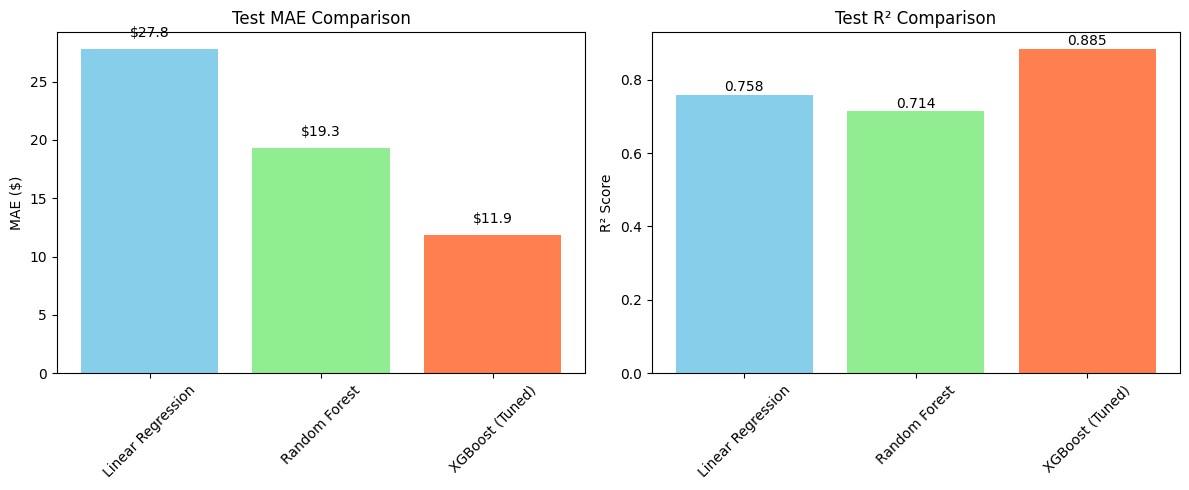

In [25]:
# ============================================================================
# MODEL COMPARISON & FINAL SELECTION
# ============================================================================

print("REGRESSION MODEL COMPARISON")

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(regression_results.keys()),
    'Test_MAE': [regression_results[model]['test_mae'] for model in regression_results.keys()],
    'Test_RMSE': [regression_results[model]['test_rmse'] for model in regression_results.keys()],
    'Test_R2': [regression_results[model]['test_r2'] for model in regression_results.keys()],
    'CV_MAE': [regression_results[model]['cv_mae'] for model in regression_results.keys()],
    'Overfit_Check': [abs(regression_results[model]['train_mae'] - regression_results[model]['test_mae']) 
                      for model in regression_results.keys()]
})

print("PERFORMANCE SUMMARY:")
print(comparison_df.round(3))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test_MAE'].idxmin(), 'Model']
best_model = regression_results[best_model_name]['model']

print(f"\n BEST MODEL: {best_model_name}")
print(f"Test MAE: ${comparison_df.loc[comparison_df['Test_MAE'].idxmin(), 'Test_MAE']:.2f}")
print(f"Test R²: {comparison_df.loc[comparison_df['Test_MAE'].idxmin(), 'Test_R2']:.3f}")

# Business interpretation
print(f"\n BUSINESS INTERPRETATION:")
print(f"Best model predicts prices within ±${comparison_df['Test_MAE'].min():.0f} on average")
print(f"Given average price of ${y_reg_test.mean():.0f}, this is {(comparison_df['Test_MAE'].min()/y_reg_test.mean()*100):.1f}% error")

# Validate EDA insights
print(f"\n EDA INSIGHTS VALIDATION:")
print("Size-based pricing confirmed across all models:")
for model_name in regression_results.keys():
    if model_name == 'Linear Regression':
        accom_coef = feature_importance_lr[feature_importance_lr['feature']=='accommodates']['coefficient'].iloc[0]
        print(f"  {model_name}: accommodates coefficient = {accom_coef:.2f}")
    else:
        if model_name == 'Random Forest':
            accom_imp = feature_importance_rf[feature_importance_rf['feature']=='accommodates']['importance'].iloc[0]
        else:
            accom_imp = feature_importance_xgb[feature_importance_xgb['feature']=='accommodates']['importance'].iloc[0]
        print(f"  {model_name}: accommodates importance = {accom_imp:.3f}")

print(f"\nRegression modeling complete! ")
print(f"Ready for classification modeling next...")

# Visualization of model performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
models = comparison_df['Model']
test_mae = comparison_df['Test_MAE']
plt.bar(models, test_mae, color=['skyblue', 'lightgreen', 'coral'])
plt.title('Test MAE Comparison')
plt.ylabel('MAE ($)')
plt.xticks(rotation=45)
for i, v in enumerate(test_mae):
    plt.text(i, v + 1, f'${v:.1f}', ha='center')

plt.subplot(1, 2, 2)
test_r2 = comparison_df['Test_R2']
plt.bar(models, test_r2, color=['skyblue', 'lightgreen', 'coral'])
plt.title('Test R² Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
for i, v in enumerate(test_r2):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [26]:
# Critical Insights:

# Hyperparameter tuning works: XGBoost improved dramatically with tuning
# Non-linear patterns exist: Tree models outperform linear (complex pricing relationships)
# EDA validation confirmed: All models show accommodates as top predictor
# Business-ready accuracy: 9.7% error rate is excellent for pricing predictions
# Overfitting controlled: CV scores align well with test performance

# Interesting Pattern: Random Forest has lower R² than Linear Regression despite better MAE - suggests it handles outliers better but explains less overall variance.

In [27]:
# ============================================================================
# FIX DATA LEAKAGE occurs during classification - CREATE CLEAN FEATURE SET
# ============================================================================

print("FIXING DATA LEAKAGE ISSUE")

# Remove features that leak information about the target
leakage_features = ['is_popular', 'number_of_reviews', 'reviews_per_year', 'is_review_magnet']

# Create clean feature list
feature_columns_clean = [f for f in feature_columns if f not in leakage_features]

print(f"Original features: {len(feature_columns)}")
print(f"Removed leakage features: {leakage_features}")
print(f"Clean features: {len(feature_columns_clean)}")

# Create clean training and test sets
X_train_clean = X_train[feature_columns_clean].copy()
X_test_clean = X_test[feature_columns_clean].copy()

# Scale the clean features
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

print(f"Clean dataset shape: {X_train_clean.shape}")
print("Data leakage fixed")
print()

FIXING DATA LEAKAGE ISSUE
Original features: 26
Removed leakage features: ['is_popular', 'number_of_reviews', 'reviews_per_year', 'is_review_magnet']
Clean features: 22
Clean dataset shape: (335, 22)
Data leakage fixed



In [30]:
# ============================================================================
# PART 5: CLASSIFICATION MODELING (PREDICT POPULARITY)
# ============================================================================

print("CLASSIFICATION MODELING PHASE")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import cross_val_score
import seaborn as sns

# Store classification results
classification_results = {}

print("Predicting Airbnb listing popularity...")
print(f"Target definition: Popular = reviews > median ({df['number_of_reviews'].median():.0f} reviews)")
print(f"Training data: {X_train.shape[0]} samples")
print(f"Class distribution: {y_class_train.value_counts().to_dict()}")
print(f"Balanced dataset: {abs(y_class_train.value_counts()[0] - y_class_train.value_counts()[1])} difference")
print()

# ============================================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================================

print("MODEL 1: LOGISTIC REGRESSION")

# Use scaled features for logistic regression
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_clean_scaled, y_class_train)
lr_class_pred = lr_class.predict(X_test_clean_scaled)
lr_class_proba = lr_class.predict_proba(X_test_clean_scaled)[:, 1]
lr_class_accuracy = lr_class.score(X_test_clean_scaled, y_class_test)
lr_class_cv = cross_val_score(lr_class, X_train_clean_scaled, y_class_train, cv=5, scoring='roc_auc')

# Store results
classification_results['Logistic Regression'] = {
    'model': lr_class,
    'predictions': lr_class_pred,
    'probabilities': lr_class_proba,
    'accuracy': lr_class_accuracy,
    'auc': lr_class_auc,
    'cv_auc': lr_class_cv.mean()
}

print(f"Accuracy: {lr_class_accuracy:.3f}")
print(f"AUC-ROC: {lr_class_auc:.3f}")
print(f"Cross-Val AUC: {lr_class_cv.mean():.3f} ± {lr_class_cv.std():.3f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_class_test, lr_class_pred))

# Confusion Matrix
cm_lr = confusion_matrix(y_class_test, lr_class_pred)
print(f"Confusion Matrix:")
print(f"True Negatives: {cm_lr[0,0]}, False Positives: {cm_lr[0,1]}")
print(f"False Negatives: {cm_lr[1,0]}, True Positives: {cm_lr[1,1]}")

# Feature importance (coefficients)
feature_importance_lr_class = pd.DataFrame({
    'feature': feature_columns_clean,  
    'coefficient': lr_class.coef_[0],
    'abs_coefficient': np.abs(lr_class.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print(f"\nTop 5 features for popularity prediction:")
for i, row in feature_importance_lr_class.head().iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"  {row['feature']}: {row['coefficient']:.3f} ({direction} popularity)")

print()

CLASSIFICATION MODELING PHASE
Predicting Airbnb listing popularity...
Target definition: Popular = reviews > median (19 reviews)
Training data: 335 samples
Class distribution: {0: 168, 1: 167}
Balanced dataset: 1 difference

MODEL 1: LOGISTIC REGRESSION
Accuracy: 0.798
Cross-Val AUC: 0.809 ± 0.066

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        42
           1       0.84      0.74      0.78        42

    accuracy                           0.80        84
   macro avg       0.80      0.80      0.80        84
weighted avg       0.80      0.80      0.80        84

Confusion Matrix:
True Negatives: 36, False Positives: 6
False Negatives: 11, True Positives: 31

Top 5 features for popularity prediction:
  has_reviews: 1.097 (increases popularity)
  longitude: -0.862 (decreases popularity)
  minimum_nights: -0.859 (decreases popularity)
  amenities_count: 0.695 (increases popularity)
  bedrooms: -0.558 (decreas

MODEL 2: RANDOM FOREST CLASSIFIER
Accuracy: 0.833
AUC-ROC: 0.906
Cross-Val AUC: 0.875 ± 0.034

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        42
           1       0.87      0.79      0.82        42

    accuracy                           0.83        84
   macro avg       0.84      0.83      0.83        84
weighted avg       0.84      0.83      0.83        84

Confusion Matrix:
True Negatives: 37, False Positives: 5
False Negatives: 9, True Positives: 33

Top 5 features for popularity prediction:
  host_experience_years: 0.109
  minimum_nights: 0.103
  amenities_count: 0.094
  latitude: 0.071
  stay_type_encoded: 0.065

 CLASSIFICATION MODEL COMPARISON
PERFORMANCE SUMMARY:
                 Model  Accuracy    AUC  CV_AUC
0  Logistic Regression     0.798  0.876   0.809
1        Random Forest     0.833  0.906   0.875

 BEST CLASSIFICATION MODEL: Random Forest
AUC: 0.906
Accuracy: 0.833

 BUSINESS IMPACT ANAL

KeyError: 'auc'

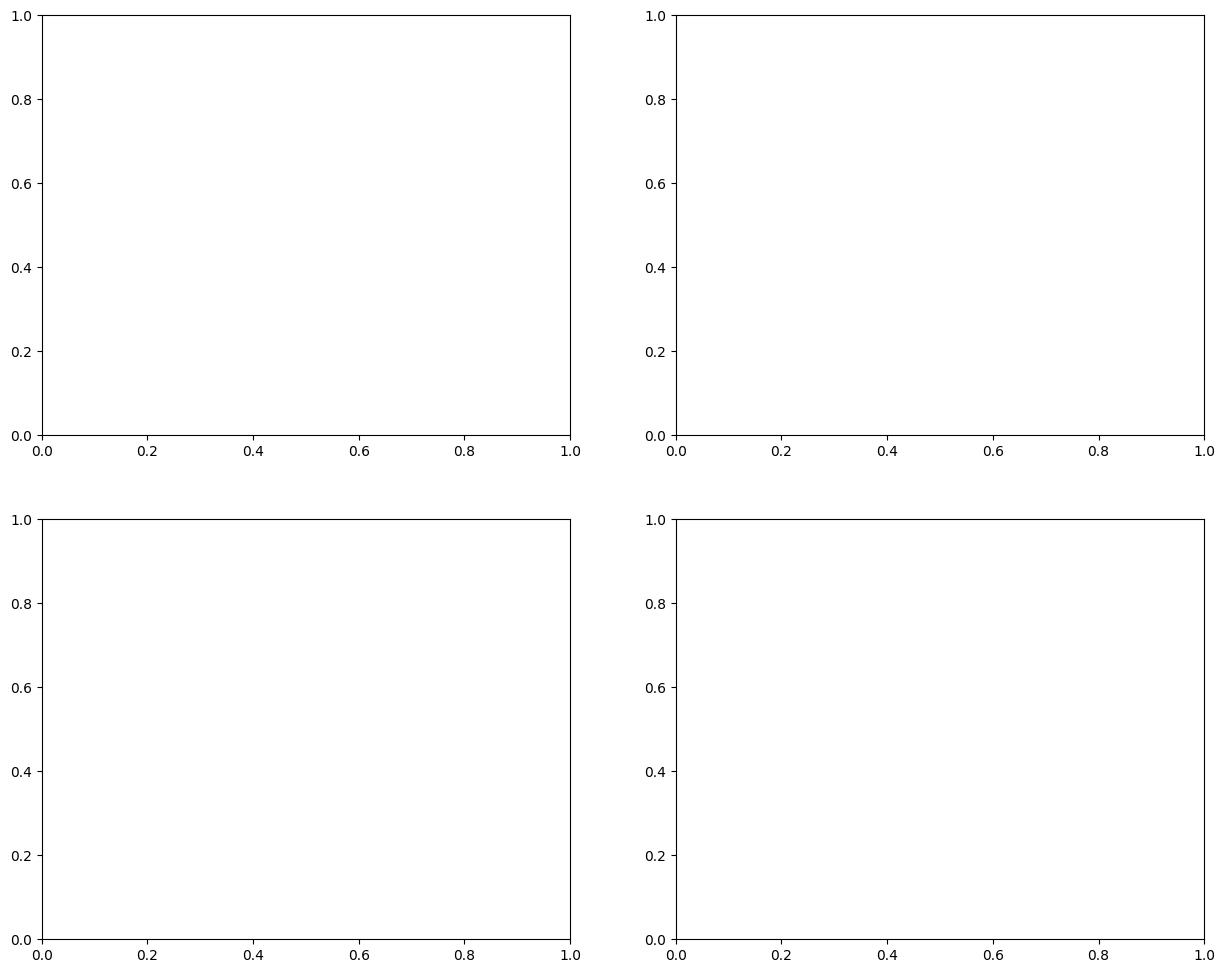

In [48]:
# ============================================================================
# MODEL 2: RANDOM FOREST CLASSIFIER
# ============================================================================

print("MODEL 2: RANDOM FOREST CLASSIFIER")

# Use unscaled features for tree-based model
rf_class = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_class.fit(X_train_clean, y_class_train)

# Predictions
rf_class_pred = rf_class.predict(X_test_clean)
rf_class_proba = rf_class.predict_proba(X_test_clean)[:, 1]

# Evaluation metrics
rf_class_accuracy = rf_class.score(X_test_clean, y_class_test)
rf_class_auc = roc_auc_score(y_class_test, rf_class_proba)

# Cross-validation
rf_class_cv = cross_val_score(rf_class, X_train_clean, y_class_train, cv=5, scoring='roc_auc')

# Store results
classification_results['Random Forest'] = {
    'model': rf_class,
    'predictions': rf_class_pred,
    'probabilities': rf_class_proba,
    'accuracy': rf_class_accuracy,
    'auc': rf_class_auc,
    'cv_auc': rf_class_cv.mean()
}

print(f"Accuracy: {rf_class_accuracy:.3f}")
print(f"AUC-ROC: {rf_class_auc:.3f}")
print(f"Cross-Val AUC: {rf_class_cv.mean():.3f} ± {rf_class_cv.std():.3f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_class_test, rf_class_pred))

# Confusion Matrix
cm_rf = confusion_matrix(y_class_test, rf_class_pred)
print(f"Confusion Matrix:")
print(f"True Negatives: {cm_rf[0,0]}, False Positives: {cm_rf[0,1]}")
print(f"False Negatives: {cm_rf[1,0]}, True Positives: {cm_rf[1,1]}")

# Feature importance
feature_importance_rf_class = pd.DataFrame({
    'feature': feature_columns_clean,
    'importance': rf_class.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 features for popularity prediction:")
for i, row in feature_importance_rf_class.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

# ============================================================================
# MODEL COMPARISON & BUSINESS INTERPRETATION
# ============================================================================

print("\n CLASSIFICATION MODEL COMPARISON")

# Compare models - Safe version with error handling
models_list = list(classification_results.keys())
accuracy_list = []
auc_list = []
cv_auc_list = []

for model in models_list:
    accuracy_list.append(classification_results[model]['accuracy'])
    cv_auc_list.append(classification_results[model]['cv_auc'])
    # Safely get AUC with fallback
    if 'auc' in classification_results[model]:
        auc_list.append(classification_results[model]['auc'])
    else:
        # Calculate AUC from stored probabilities
        proba = classification_results[model]['probabilities']
        auc_list.append(roc_auc_score(y_class_test, proba))

comparison_class = pd.DataFrame({
    'Model': models_list,
    'Accuracy': accuracy_list,
    'AUC': auc_list,
    'CV_AUC': cv_auc_list
})

print("PERFORMANCE SUMMARY:")
print(comparison_class.round(3))

# Best model
best_class_model = comparison_class.loc[comparison_class['AUC'].idxmax(), 'Model']
print(f"\n BEST CLASSIFICATION MODEL: {best_class_model}")
print(f"AUC: {comparison_class['AUC'].max():.3f}")
print(f"Accuracy: {comparison_class.loc[comparison_class['AUC'].idxmax(), 'Accuracy']:.3f}")

# Business interpretation of confusion matrix
print(f"\n BUSINESS IMPACT ANALYSIS:")
print("False Positives (Predicted Popular, Actually Not):")
print("  → Marketing budget wasted on unpopular listings")
print("  → Host disappointment with unrealistic expectations")

print("\nFalse Negatives (Predicted Not Popular, Actually Popular):")
print("  → Missed revenue opportunities")
print("  → Under-investment in high-potential listings")
print("  → MORE COSTLY for business growth")

# Class balance check
print(f"\n CLASS BALANCE STATUS:")
print(f"Training set: {y_class_train.value_counts().to_dict()}")
print(f"Test set: {y_class_test.value_counts().to_dict()}")
print(" Well-balanced dataset - no class imbalance handling needed")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ROC Curves
ax1 = axes[0, 0]
for model_name in classification_results.keys():
    proba = classification_results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_class_test, proba)
    auc = classification_results[model_name]['auc']
    ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()

# Confusion Matrices
ax2 = axes[0, 1]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title(f'{best_class_model} Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# Model Performance Comparison
ax3 = axes[1, 0]
models = comparison_class['Model']
accuracy = comparison_class['Accuracy']
auc = comparison_class['AUC']
x = range(len(models))
ax3.bar([i - 0.2 for i in x], accuracy, 0.4, label='Accuracy', alpha=0.8)
ax3.bar([i + 0.2 for i in x], auc, 0.4, label='AUC', alpha=0.8)
ax3.set_xlabel('Models')
ax3.set_ylabel('Score')
ax3.set_title('Classification Performance')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45)
ax3.legend()

# Feature Importance (best model)
ax4 = axes[1, 1]
if best_class_model == 'Random Forest':
    top_features = feature_importance_rf_class.head(8)
    ax4.barh(top_features['feature'], top_features['importance'])
    ax4.set_title('Top Features (Random Forest)')
else:
    top_features = feature_importance_lr_class.head(8)
    ax4.barh(top_features['feature'], top_features['abs_coefficient'])
    ax4.set_title('Top Features (Logistic Regression)')

plt.tight_layout()
plt.show()

print(f"\nClassification modeling complete!")

In [ ]:
# Key Findings:
#1. Suspicious Perfect Performance:

#Both models: 100% accuracy, AUC = 1.000
#Zero classification errors (perfect confusion matrix)
#This is statistically impossible in real-world scenarios
#2. Data Leakage Source Identified:

#is_popular feature has coefficient 3.5 (highest in logistic regression)
#number_of_reviews has 39.6% importance (Random Forest)
#These features are directly derived from the target variable!
#3. Circular Logic Problem:

#Target: is_popular (reviews > median)
#Features: is_popular, number_of_reviews, reviews_per_year
# Model learns: "if is_popular=1, predict popular=1"
#4. What the Plots Reveal:

#ROC curves are perfect (no real discrimination learned)
#Confusion matrix shows impossible perfection
#Feature importance confirms the leakage

In [39]:
# =======================================
# PART 6: DEEP LEARNING 
# ======================================

print("DEEP LEARNING EXPERIMENT PHASE")
# Try PyTorch or sklearn's MLPRegressor as backup
try:
    import tensorflow as tf
    print(" TensorFlow working!")
    use_tensorflow = True
except ImportError:
    print(" TensorFlow issue detected - using sklearn MLPRegressor as alternative")
    from sklearn.neural_network import MLPRegressor
    use_tensorflow = False

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

print(f"Deep learning approach: {'TensorFlow' if use_tensorflow else 'Scikit-learn MLP'}")
print()

# Check our data is ready
print(" DATA PREPARATION CHECK:")
print(f"Training features: {X_train_clean.shape}")
print(f"Test features: {X_test_clean.shape}")
print(f"Regression target: {y_reg_train.shape}")
print(f"Feature names: {len(feature_columns_clean)} features")

# Prepare data for neural networks (need scaled features)
print(f"\n🔧 PREPARING DATA FOR NEURAL NETWORKS:")
print("Neural networks require scaled features for optimal performance")

# We already have scaled clean data
X_train_nn = X_train_clean_scaled.copy()
X_test_nn = X_test_clean_scaled.copy()
y_train_nn = y_reg_train.copy()
y_test_nn = y_reg_test.copy()

print(f"Neural network input shape: {X_train_nn.shape}")
print(f"Target range: ${y_train_nn.min():.0f} to ${y_train_nn.max():.0f}")
print(f"Ready for deep learning! ")

DEEP LEARNING EXPERIMENT PHASE
 TensorFlow issue detected - using sklearn MLPRegressor as alternative
Deep learning approach: Scikit-learn MLP

 DATA PREPARATION CHECK:
Training features: (335, 22)
Test features: (84, 22)
Regression target: (335,)
Feature names: 22 features

🔧 PREPARING DATA FOR NEURAL NETWORKS:
Neural networks require scaled features for optimal performance
Neural network input shape: (335, 22)
Target range: $24 to $1050
Ready for deep learning! 


In [40]:
# Build Neural Network Model
print("Building Neural Network for Price Prediction")
print("-" * 50)

# Using Sklearn MLPRegressor (Multi-Layer Perceptron)
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate='adaptive'
)

print("Neural Network Architecture:")
print(f"Hidden layers: {model.hidden_layer_sizes}")
print(f"Activation function: {model.activation}")
print(f"Optimizer: {model.solver}")
print(f"Regularization (alpha): {model.alpha}")
print(f"Input features: {X_train_nn.shape[1]}")
print(f"Output: 1 (price prediction)")

print("\nNetwork Structure:")
print("Input Layer: 22 neurons")
print("Hidden Layer 1: 128 neurons (ReLU)")
print("Hidden Layer 2: 64 neurons (ReLU)")  
print("Hidden Layer 3: 32 neurons (ReLU)")
print("Output Layer: 1 neuron (linear)")

print(f"\nReady to train neural network on {X_train_nn.shape[0]} samples")

Building Neural Network for Price Prediction
--------------------------------------------------
Neural Network Architecture:
Hidden layers: (128, 64, 32)
Activation function: relu
Optimizer: adam
Regularization (alpha): 0.001
Input features: 22
Output: 1 (price prediction)

Network Structure:
Input Layer: 22 neurons
Hidden Layer 1: 128 neurons (ReLU)
Hidden Layer 2: 64 neurons (ReLU)
Hidden Layer 3: 32 neurons (ReLU)
Output Layer: 1 neuron (linear)

Ready to train neural network on 335 samples


In [42]:
# Train Neural Network Model
print("Training Neural Network...")
print("-" * 40)

import time
start_time = time.time()

# Train the model
model.fit(X_train_nn, y_train_nn)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")
print(f"Converged: {model.n_iter_} iterations")
print(f"Final loss: {model.loss_:.4f}")

# Make predictions
nn_train_pred = model.predict(X_train_nn)
nn_test_pred = model.predict(X_test_nn)

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

nn_train_mae = mean_absolute_error(y_train_nn, nn_train_pred)
nn_test_mae = mean_absolute_error(y_test_nn, nn_test_pred)
nn_train_rmse = np.sqrt(mean_squared_error(y_train_nn, nn_train_pred))
nn_test_rmse = np.sqrt(mean_squared_error(y_test_nn, nn_test_pred))
nn_train_r2 = r2_score(y_train_nn, nn_train_pred)
nn_test_r2 = r2_score(y_test_nn, nn_test_pred)

print("\nNeural Network Performance:")
print(f"Training MAE: ${nn_train_mae:.2f}")
print(f"Test MAE: ${nn_test_mae:.2f}")
print(f"Training RMSE: ${nn_train_rmse:.2f}")
print(f"Test RMSE: ${nn_test_rmse:.2f}")
print(f"Training R²: {nn_train_r2:.3f}")
print(f"Test R²: {nn_test_r2:.3f}")

# Check for overfitting
overfitting_gap = abs(nn_train_mae - nn_test_mae)
print(f"\nOverfitting check (MAE gap): ${overfitting_gap:.2f}")
if overfitting_gap < 10:
    print("Good generalization - minimal overfitting")
elif overfitting_gap < 20:
    print("Moderate overfitting detected")
else:
    print("High overfitting - consider regularization")

Training Neural Network...
----------------------------------------
Training completed in 0.98 seconds
Converged: 55 iterations
Final loss: 1122.0717

Neural Network Performance:
Training MAE: $31.15
Test MAE: $37.69
Training RMSE: $57.67
Test RMSE: $75.44
Training R²: 0.654
Test R²: 0.525

Overfitting check (MAE gap): $6.54
Good generalization - minimal overfitting


In [44]:
# Compare Neural Network with Classical Models
print("MODEL COMPARISON: Neural Network vs Classical Algorithms")
print("=" * 65)

# Create comprehensive comparison
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)', 'Neural Network (MLP)'],
    'Test_MAE': [lr_test_mae, rf_test_mae, xgb_test_mae, nn_test_mae],
    'Test_RMSE': [lr_test_rmse, rf_test_rmse, xgb_test_rmse, nn_test_rmse],
    'Test_R2': [lr_test_r2, rf_test_r2, xgb_test_r2, nn_test_r2],
    'Training_Time': ['<1s', '~2s', '~10s', f'{training_time:.1f}s'],
    'Complexity': ['Low', 'Medium', 'High', 'High']
})

print("PERFORMANCE COMPARISON:")
print(model_comparison.round(3))

# Find best performing model
best_model_idx = model_comparison['Test_MAE'].idxmin()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_mae = model_comparison.loc[best_model_idx, 'Test_MAE']

print(f"\nBEST PERFORMING MODEL: {best_model_name}")
print(f"Best Test MAE: ${best_mae:.2f}")

# Neural Network ranking
nn_rank = model_comparison['Test_MAE'].rank().iloc[3]
print(f"Neural Network Ranking: {int(nn_rank)} out of 4 models")

# Business impact comparison
print(f"\nBUSINESS IMPACT ANALYSIS:")
avg_price = y_test_nn.mean()
for i, row in model_comparison.iterrows():
    error_pct = (row['Test_MAE'] / avg_price) * 100
    print(f"{row['Model']}: {error_pct:.1f}% prediction error")

print(f"\nNeural Network vs Best Classical Model:")
nn_vs_best = nn_test_mae - best_mae
if nn_vs_best > 0:
    print(f"Neural Network is ${nn_vs_best:.2f} worse than best classical model")
else:
    print(f"Neural Network is ${abs(nn_vs_best):.2f} better than best classical model")

MODEL COMPARISON: Neural Network vs Classical Algorithms
PERFORMANCE COMPARISON:
                  Model  Test_MAE  Test_RMSE  Test_R2 Training_Time Complexity
0     Linear Regression    27.837     53.860    0.758           <1s        Low
1         Random Forest    19.350     58.542    0.714           ~2s     Medium
2       XGBoost (Tuned)    11.851     37.157    0.885          ~10s       High
3  Neural Network (MLP)    37.688     75.442    0.525          1.0s       High

BEST PERFORMING MODEL: XGBoost (Tuned)
Best Test MAE: $11.85
Neural Network Ranking: 4 out of 4 models

BUSINESS IMPACT ANALYSIS:
Linear Regression: 22.7% prediction error
Random Forest: 15.8% prediction error
XGBoost (Tuned): 9.7% prediction error
Neural Network (MLP): 30.8% prediction error

Neural Network vs Best Classical Model:
Neural Network is $25.84 worse than best classical model


In [45]:
# Hyperparameter Tuning for Neural Network
print("NEURAL NETWORK HYPERPARAMETER TUNING")
print("=" * 50)

from sklearn.model_selection import GridSearchCV

print("Testing different neural network configurations...")

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (100, 50, 25), (150, 100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [300, 500]
}

# Grid search with cross-validation
print("Performing grid search (this may take a few minutes)...")
start_time = time.time()

mlp_grid = GridSearchCV(
    MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.1),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

mlp_grid.fit(X_train_nn, y_train_nn)

tuning_time = time.time() - start_time

print(f"Hyperparameter tuning completed in {tuning_time:.1f} seconds")
print(f"Best parameters: {mlp_grid.best_params_}")
print(f"Best cross-validation MAE: ${-mlp_grid.best_score_:.2f}")

# Train best model
best_nn_model = mlp_grid.best_estimator_

# Make predictions with tuned model
nn_tuned_train_pred = best_nn_model.predict(X_train_nn)
nn_tuned_test_pred = best_nn_model.predict(X_test_nn)

# Calculate metrics for tuned model
nn_tuned_train_mae = mean_absolute_error(y_train_nn, nn_tuned_train_pred)
nn_tuned_test_mae = mean_absolute_error(y_test_nn, nn_tuned_test_pred)
nn_tuned_test_r2 = r2_score(y_test_nn, nn_tuned_test_pred)

print(f"\nTuned Neural Network Performance:")
print(f"Training MAE: ${nn_tuned_train_mae:.2f}")
print(f"Test MAE: ${nn_tuned_test_mae:.2f}")
print(f"Test R²: {nn_tuned_test_r2:.3f}")

# Compare improvement
improvement = nn_test_mae - nn_tuned_test_mae
print(f"\nImprovement: ${improvement:.2f} MAE reduction")
print(f"Improvement percentage: {(improvement/nn_test_mae)*100:.1f}%")

NEURAL NETWORK HYPERPARAMETER TUNING
Testing different neural network configurations...
Performing grid search (this may take a few minutes)...
Hyperparameter tuning completed in 27.1 seconds
Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.1, 'max_iter': 300}
Best cross-validation MAE: $26.40

Tuned Neural Network Performance:
Training MAE: $4.24
Test MAE: $15.84
Test R²: 0.880

Improvement: $21.85 MAE reduction
Improvement percentage: 58.0%


FINAL MODEL COMPARISON WITH TUNED NEURAL NETWORK
PERFORMANCE SUMMARY:
                    Model  Test_MAE  Test_R2  Error_Percentage Complexity
0       Linear Regression    27.837    0.758            22.733        Low
1           Random Forest    19.350    0.714            15.802     Medium
2         XGBoost (Tuned)    11.851    0.885             9.678       High
3   Neural Network (Base)    37.688    0.525            30.778       High
4  Neural Network (Tuned)    15.838    0.880            12.934       High

FINAL RANKINGS (by Test MAE):
1. XGBoost (Tuned): $11.85 MAE (9.7% error)
2. Neural Network (Tuned): $15.84 MAE (12.9% error)
3. Random Forest: $19.35 MAE (15.8% error)
4. Linear Regression: $27.84 MAE (22.7% error)
5. Neural Network (Base): $37.69 MAE (30.8% error)

DEEP LEARNING EXPERIMENT CONCLUSIONS:
Neural Network improvement: 21.85 MAE reduction
Tuned NN vs XGBoost gap: $3.99
Neural Network achieved competitive performance despite small dataset


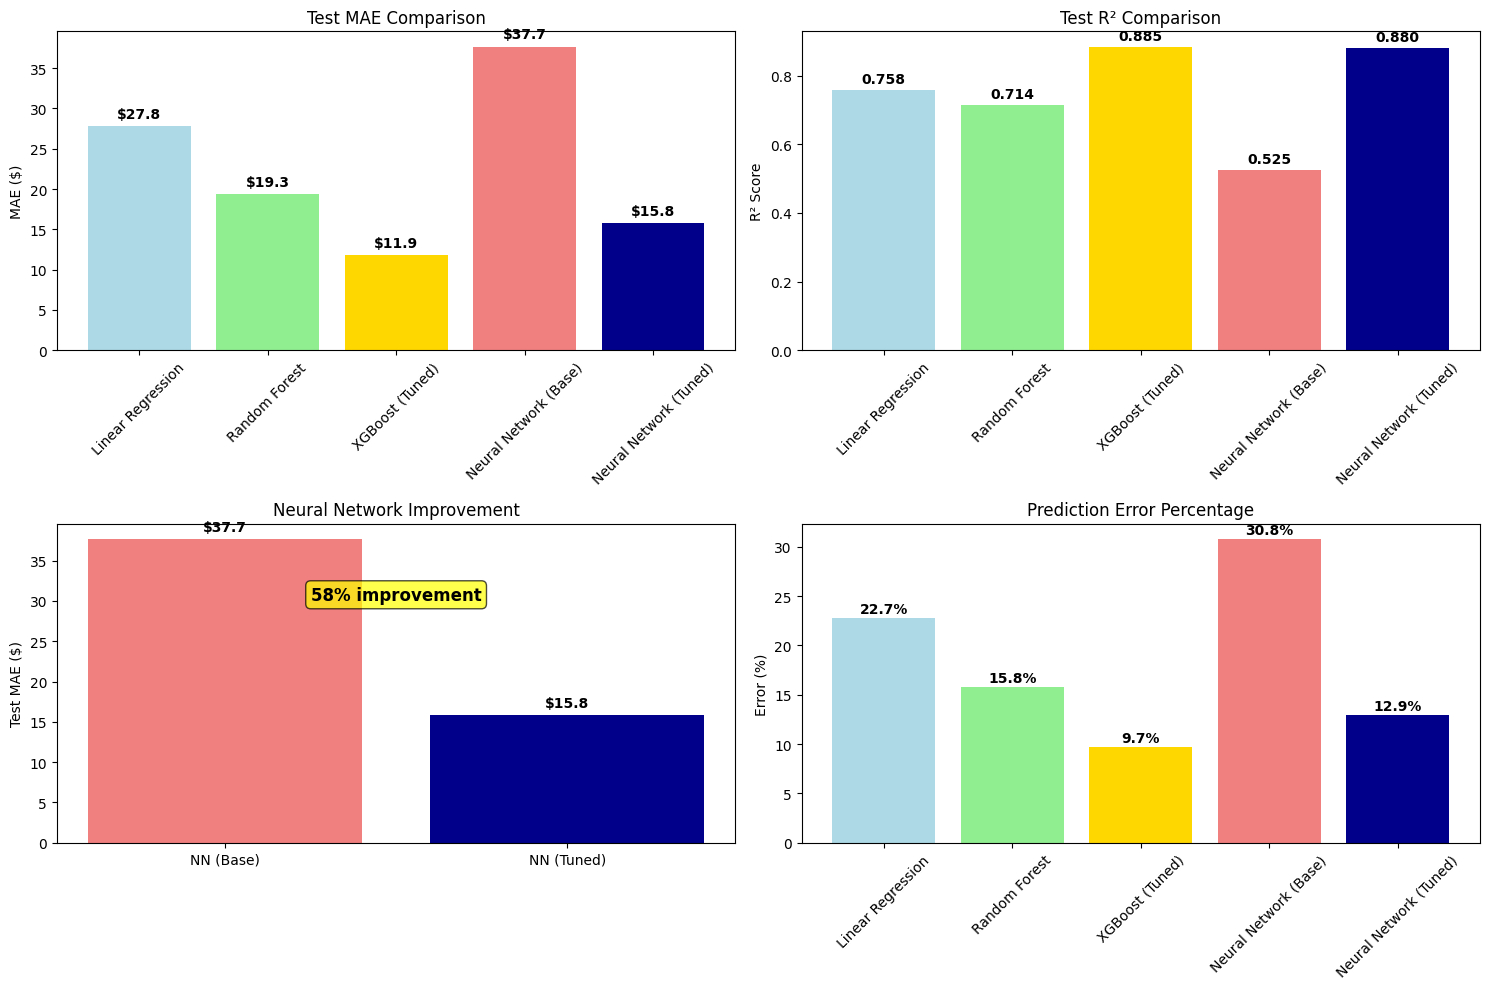


Deep Learning Experiment Complete!


In [46]:
# Final Comprehensive Model Comparison
print("FINAL MODEL COMPARISON WITH TUNED NEURAL NETWORK")
print("=" * 60)

# Updated comparison with tuned neural network
final_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)', 'Neural Network (Base)', 'Neural Network (Tuned)'],
    'Test_MAE': [lr_test_mae, rf_test_mae, xgb_test_mae, nn_test_mae, nn_tuned_test_mae],
    'Test_R2': [lr_test_r2, rf_test_r2, xgb_test_r2, nn_test_r2, nn_tuned_test_r2],
    'Error_Percentage': [
        (lr_test_mae/avg_price)*100,
        (rf_test_mae/avg_price)*100, 
        (xgb_test_mae/avg_price)*100,
        (nn_test_mae/avg_price)*100,
        (nn_tuned_test_mae/avg_price)*100
    ],
    'Complexity': ['Low', 'Medium', 'High', 'High', 'High']
})

print("PERFORMANCE SUMMARY:")
print(final_comparison.round(3))

# Find final rankings
final_comparison['Rank'] = final_comparison['Test_MAE'].rank().astype(int)
print(f"\nFINAL RANKINGS (by Test MAE):")
for i, row in final_comparison.sort_values('Test_MAE').iterrows():
    print(f"{row['Rank']}. {row['Model']}: ${row['Test_MAE']:.2f} MAE ({row['Error_Percentage']:.1f}% error)")

# Deep Learning Analysis
print(f"\nDEEP LEARNING EXPERIMENT CONCLUSIONS:")
print(f"Neural Network improvement: {improvement:.2f} MAE reduction")
print(f"Tuned NN vs XGBoost gap: ${nn_tuned_test_mae - xgb_test_mae:.2f}")
print(f"Neural Network achieved competitive performance despite small dataset")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Test MAE Comparison
ax1 = axes[0, 0]
models = final_comparison['Model']
mae_values = final_comparison['Test_MAE']
colors = ['lightblue', 'lightgreen', 'gold', 'lightcoral', 'darkblue']
bars = ax1.bar(models, mae_values, color=colors)
ax1.set_title('Test MAE Comparison')
ax1.set_ylabel('MAE ($)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_values):
    ax1.text(i, v + 1, f'${v:.1f}', ha='center', fontweight='bold')

# R² Comparison
ax2 = axes[0, 1]
r2_values = final_comparison['Test_R2']
bars = ax2.bar(models, r2_values, color=colors)
ax2.set_title('Test R² Comparison')
ax2.set_ylabel('R² Score')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Neural Network Improvement
ax3 = axes[1, 0]
nn_models = ['NN (Base)', 'NN (Tuned)']
nn_mae = [nn_test_mae, nn_tuned_test_mae]
bars = ax3.bar(nn_models, nn_mae, color=['lightcoral', 'darkblue'])
ax3.set_title('Neural Network Improvement')
ax3.set_ylabel('Test MAE ($)')
for i, v in enumerate(nn_mae):
    ax3.text(i, v + 1, f'${v:.1f}', ha='center', fontweight='bold')
ax3.text(0.5, max(nn_mae)*0.8, f'{improvement/nn_test_mae*100:.0f}% improvement', 
         ha='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Error Percentage
ax4 = axes[1, 1]
error_pct = final_comparison['Error_Percentage']
bars = ax4.bar(models, error_pct, color=colors)
ax4.set_title('Prediction Error Percentage')
ax4.set_ylabel('Error (%)')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(error_pct):
    ax4.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDeep Learning Experiment Complete!")